# E-commerce Marketing Campaign — Exploratory Data Analysis (EDA)

This notebook performs an end-to-end, **advanced EDA** on the `train.csv` dataset.

## What you'll find here
- Data overview + quality checks (missing values, duplicates, types)
- Feature engineering (time features + marketing KPIs)
- Univariate + bivariate analysis (categorical + numerical)
- Outlier & skewness checks
- Correlation analysis
- Time trends and segment/channel performance

**Target / business outcome:** `sales_revenue`


## Data description

Dataset file: `train.csv`

### Columns
- Identifiers / time: `id`, `date`
- Categorical: `region`, `channel`, `product_category`, `customer_segment`
- Spend/price/promo: `ad_spend`, `price`, `discount_rate`, `campaign_duration_days`
- Reach/traffic: `market_reach`, `impressions`, `click_through_rate`
- Competitive/seasonal: `competition_index`, `seasonality_index`
- Customer metric: `customer_lifetime_value`
- Target: `sales_revenue`


In [2]:
# Core libraries
import numpy as np
import pandas as pd
from IPython.display import display

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Optional stats helpers
try:
    from scipy import stats
except Exception:
    stats = None

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")


## 1) Load data


In [3]:
df = pd.read_csv("train.csv")
df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [4]:
print("Shape:", df.shape)
display(df.sample(5, random_state=42))

Shape: (18000, 17)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
2574,2575,2009-12-10 12:21:00,North,Search,Stationery,Premium,5.04,0.42,NaN,177.0,2104,0.0418,0.56,1.000000,14.0,1108.34,253.357017
7496,7497,2010-09-16 16:25:00,North,Social Media,Stationery,Premium,NaN,1.25,0.5530,130.0,1557,0.0331,3.85,-1.000000,21.0,974.67,86.667528
9210,9211,2011-08-26 11:35:00,Norht,Email,Stationery,Premium,49.50,4.95,0.0293,254.0,6082,0.0903,3.86,-1.366025,NaN,419.56,76.098589
5456,5457,2010-04-28 13:12:00,North,Search,Storage,Premium,19.50,1.95,0.4400,549.0,6703,0.0266,1.29,0.366025,90.0,1613.79,181.344338
736,737,2010-10-18 12:25:00,North,Email,General,Premium,10.20,0.85,0.3675,161.0,5656,0.1791,4.53,-0.366025,30.0,23666.60,184.993229


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

## 2) Data quality checks

We inspect:
- Missing values
- Duplicates
- Basic summary statistics


In [6]:
def missing_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    miss_cnt = dataframe.isna().sum()
    miss_pct = (miss_cnt / len(dataframe) * 100).round(2)
    out = (
        pd.DataFrame({"missing_count": miss_cnt, "missing_pct": miss_pct})
        .sort_values("missing_count", ascending=False)
    )
    return out[out.missing_count > 0]

missing_report(df)

,missing_count,missing_pct
campaign_duration_days,1513,8.41
discount_rate,755,4.19
customer_lifetime_value,743,4.13
click_through_rate,713,3.96
competition_index,707,3.93
market_reach,686,3.81
ad_spend,658,3.66


In [7]:
dup_count = df.duplicated().sum()
dup_count

np.int64(0)

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,18000.0,NaN,NaN,NaN,9000.5,5196.296758,1.0,4500.75,9000.5,13500.25,18000.0
date,18000,11926,2011-11-28 15:54:00,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,18000,10,North,16305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,18000,11,Social Media,4246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,18000,6,General,8984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,18000,3,Premium,14445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_spend,17342.0,NaN,NaN,NaN,44.071797,190.16545,0.18,4.95,11.9,19.8,4254.5
price,18000.0,NaN,NaN,NaN,5.648265,22.456661,0.04,1.25,1.95,3.75,295.0
discount_rate,17245.0,NaN,NaN,NaN,0.230045,0.149955,0.0002,0.1095,0.204,0.3249,0.6
market_reach,17314.0,NaN,NaN,NaN,321.393323,244.853653,1.0,138.0,269.0,439.0,1490.0


## 3) Basic preprocessing

- Parse `date`
- Clean string columns (strip/standardize)
- Convert numeric columns (defensive)
- Drop duplicates


In [9]:
df = df.copy()

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Clean categorical text columns
cat_base = ["region", "channel", "product_category", "customer_segment"]
for col in cat_base:
    df[col] = df[col].astype("string").str.strip()

# Light standardization
df["region"] = df["region"].str.title().replace({"Nort": "North"})
df["channel"] = df["channel"].str.title()
df["product_category"] = df["product_category"].str.title()
df["customer_segment"] = df["customer_segment"].str.title()

# Convert numerics (defensive)
numeric_cols = [
    "ad_spend",
    "price",
    "discount_rate",
    "market_reach",
    "impressions",
    "click_through_rate",
    "competition_index",
    "seasonality_index",
    "campaign_duration_days",
    "customer_lifetime_value",
    "sales_revenue",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Dropped duplicates:", before - len(df))

df.head()

Dropped duplicates: 0


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,North,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## 4) Feature engineering

We create:
- Time features from `date`
- Effective price after discount
- Simple marketing KPIs (ROAS/ROI, revenue per impression)


In [10]:
# Time features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()
df["hour"] = df["date"].dt.hour

# Price features
df["effective_price"] = df["price"] * (1 - df["discount_rate"].clip(0, 1))

# KPI features (handle divide-by-zero)
df["roas"] = df["sales_revenue"] / df["ad_spend"].replace(0, np.nan)
df["roi"] = (df["sales_revenue"] - df["ad_spend"]) / df["ad_spend"].replace(0, np.nan)
df["revenue_per_impression"] = df["sales_revenue"] / df["impressions"].replace(0, np.nan)

# Estimated clicks and CPC (based on impressions + CTR)
df["est_clicks"] = df["impressions"] * df["click_through_rate"].clip(lower=0)
df["est_cpc"] = df["ad_spend"] / df["est_clicks"].replace(0, np.nan)

df[["date", "effective_price", "roas", "roi", "revenue_per_impression", "est_clicks", "est_cpc"]].head()

,date,effective_price,roas,roi,revenue_per_impression,est_clicks,est_cpc
0,2011-12-05 11:31:00,0.541350,13.307535,12.307535,0.146595,0.8170,11.015912
1,2011-04-27 14:01:00,3.044480,35.643183,34.643183,0.052165,146.4960,0.022868
2,2010-11-09 15:20:00,2.040765,51.768528,50.768528,0.008982,2216.3076,0.001151
3,2010-10-03 15:24:00,1.543735,52.376866,51.376866,0.008790,3454.0770,0.000854
4,2011-10-14 09:28:00,0.808000,8.537328,7.537328,0.020392,125.6000,0.119427


## 5) Separate categorical vs numerical columns

We will use these lists throughout the analysis.


In [11]:
cats = [
    "region",
    "channel",
    "product_category",
    "customer_segment",
    "day_of_week",
]

# Treat month/hour as categorical for distribution comparisons
cats += ["month", "hour"]

nums = [c for c in df.columns if c not in cats and c not in ["id", "date"]]

print("Categorical columns:", cats)
print("Numerical columns:", nums)

Categorical columns: ['region', 'channel', 'product_category', 'customer_segment', 'day_of_week', 'month', 'hour']
Numerical columns: ['ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue', 'year', 'day', 'effective_price', 'roas', 'roi', 'revenue_per_impression', 'est_clicks', 'est_cpc']


## 6) Target overview (`sales_revenue`)


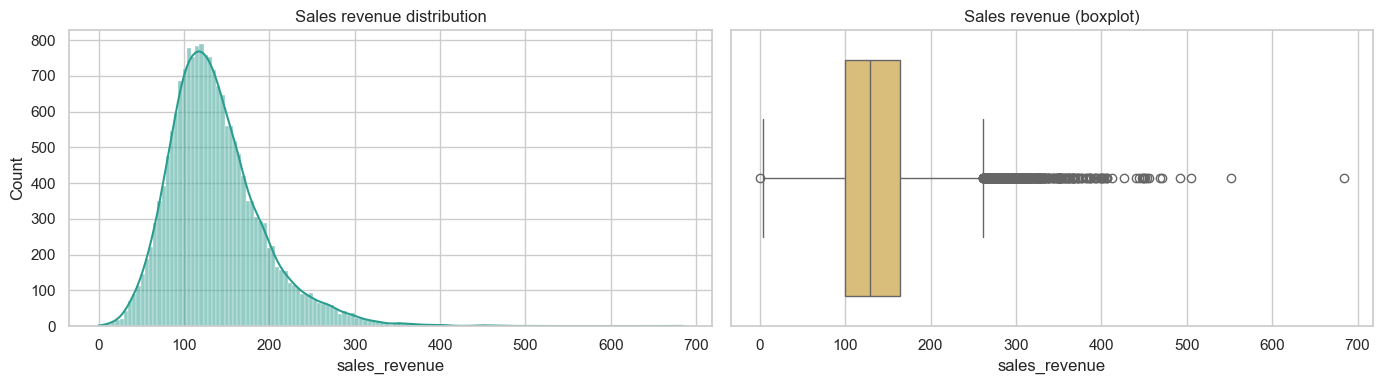

In [12]:
target = "sales_revenue"

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[target], kde=True, ax=ax[0], color="#2a9d8f")
ax[0].set_title("Sales revenue distribution")

sns.boxplot(x=df[target], ax=ax[1], color="#e9c46a")
ax[1].set_title("Sales revenue (boxplot)")

plt.tight_layout()
plt.show()

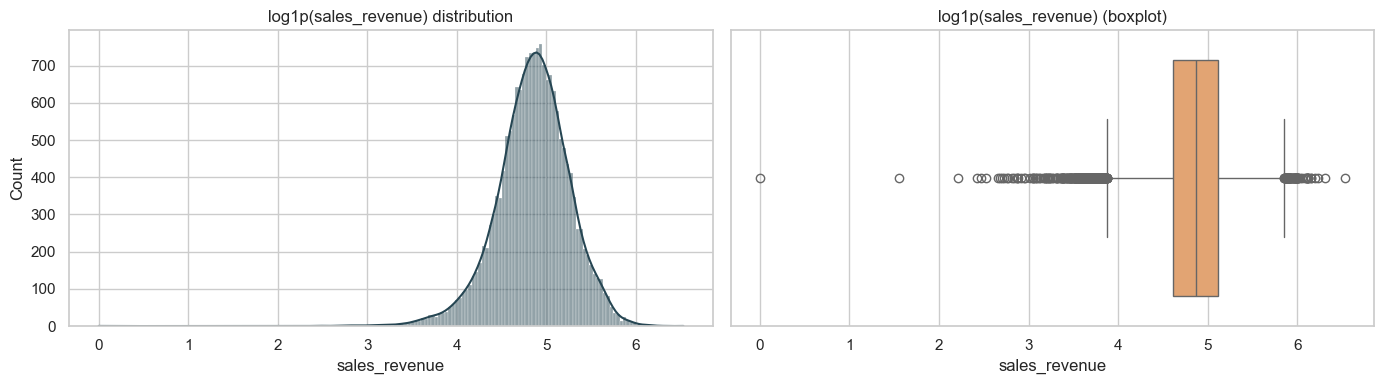

In [13]:
# Log view (useful if heavily right-skewed)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(np.log1p(df[target]), kde=True, ax=ax[0], color="#264653")
ax[0].set_title("log1p(sales_revenue) distribution")

sns.boxplot(x=np.log1p(df[target]), ax=ax[1], color="#f4a261")
ax[1].set_title("log1p(sales_revenue) (boxplot)")

plt.tight_layout()
plt.show()

## 7) Analysis on categorical attributes

We inspect:
- Category frequency
- Category impact on `sales_revenue`
- Interactions (e.g., region × channel)


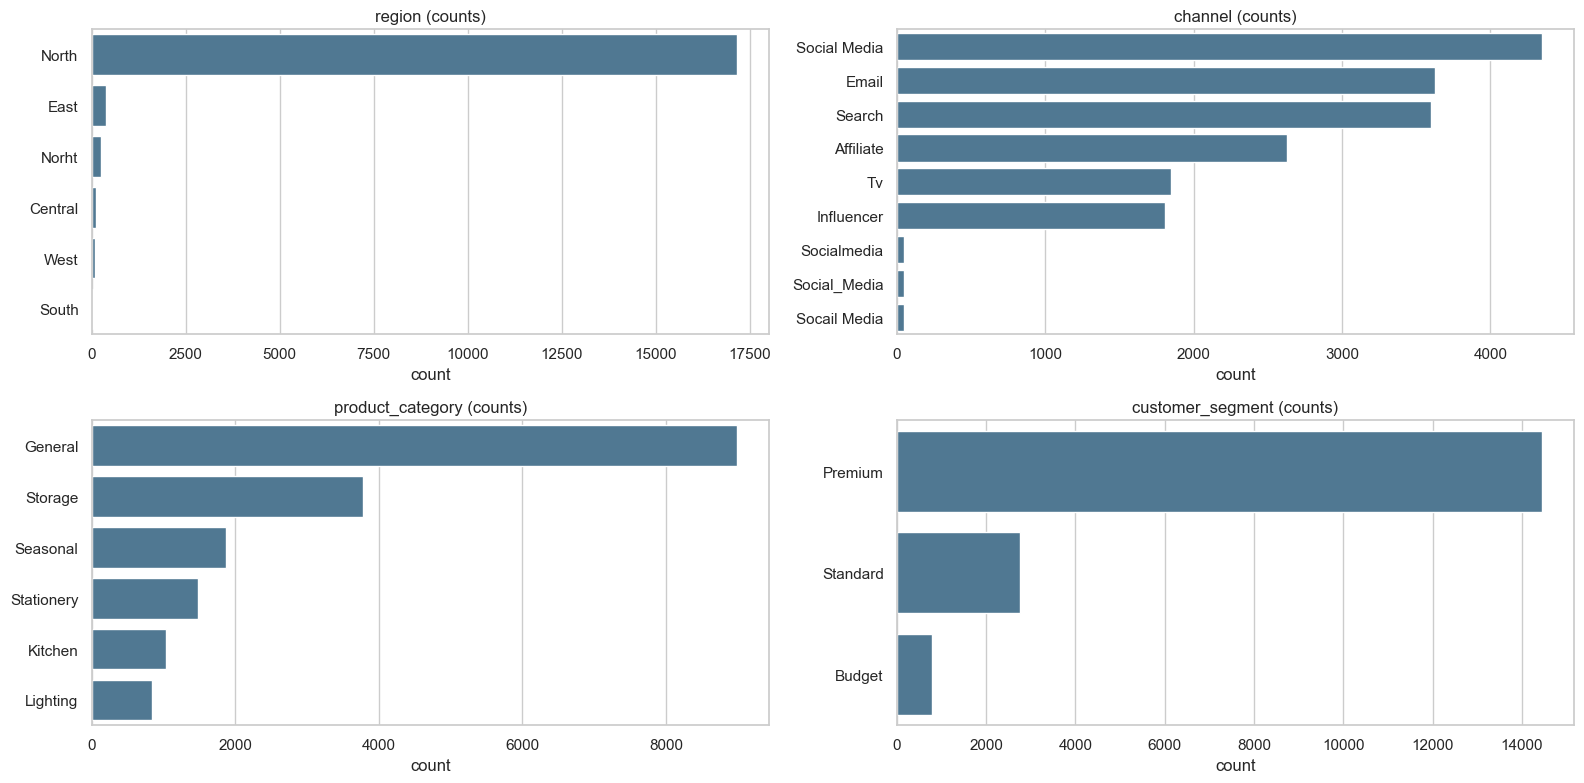

In [14]:
def plot_cat_counts(dataframe: pd.DataFrame, columns, ncols=2, top_n=None):
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        ax = axes[i]
        series = dataframe[col]
        if top_n is not None:
            order = series.value_counts().head(top_n).index
        else:
            order = series.value_counts().index

        sns.countplot(data=dataframe, y=col, order=order, ax=ax, color="#457b9d")
        ax.set_title(f"{col} (counts)")
        ax.set_xlabel("count")
        ax.set_ylabel("")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_cat_counts(df, ["region", "channel", "product_category", "customer_segment"], ncols=2)

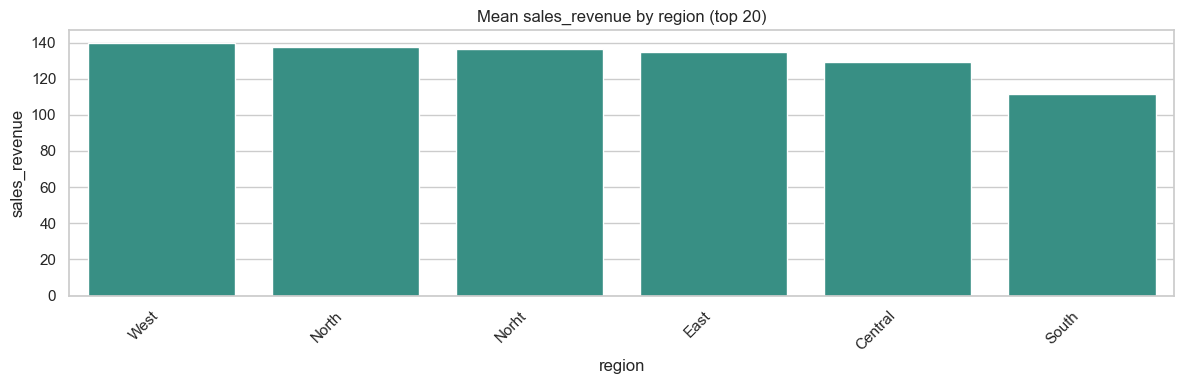

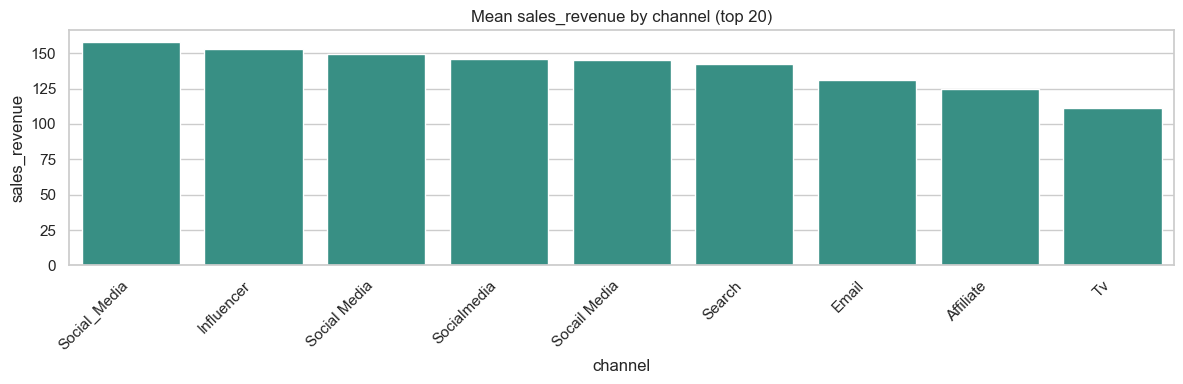

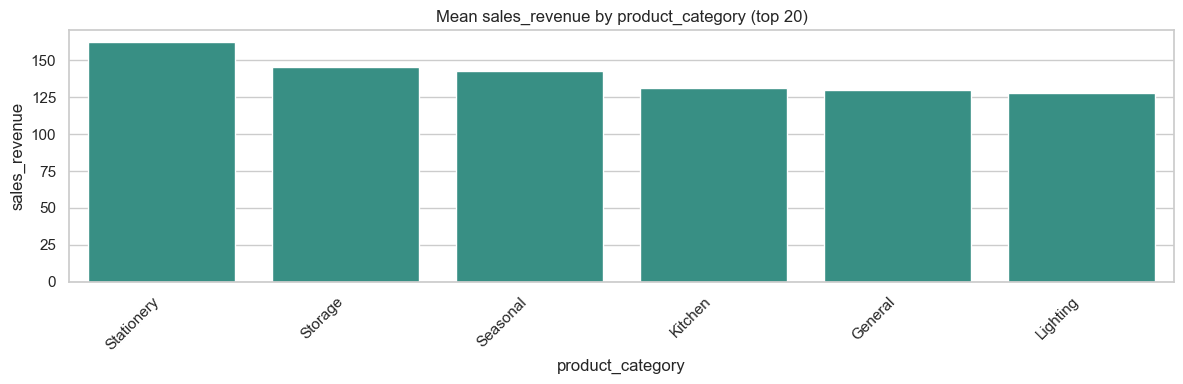

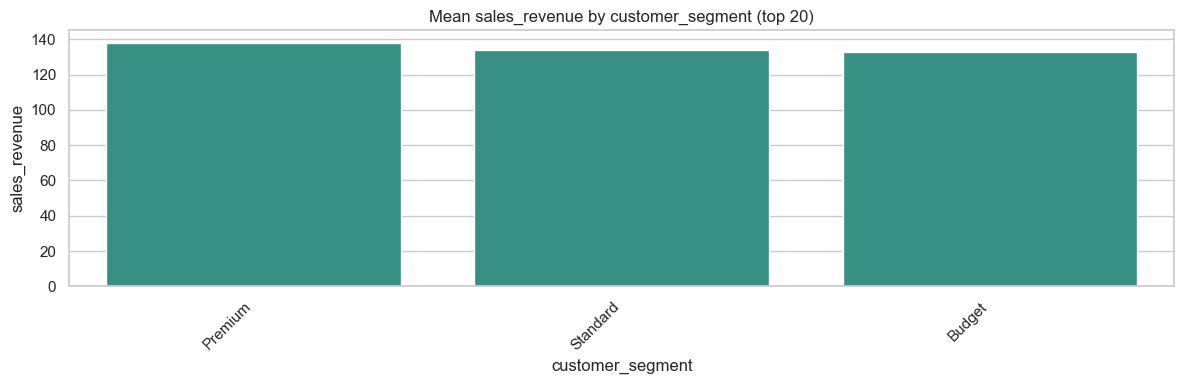

In [15]:
def plot_cat_target_mean(dataframe: pd.DataFrame, cat_col: str, target_col: str, top_n=15):
    tmp = (
        dataframe.groupby(cat_col, dropna=False)[target_col]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    plt.figure(figsize=(12, 4))
    sns.barplot(data=tmp, x=cat_col, y=target_col, color="#2a9d8f")
    plt.title(f"Mean {target_col} by {cat_col} (top {top_n})")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in ["region", "channel", "product_category", "customer_segment"]:
    plot_cat_target_mean(df, col, target, top_n=20)

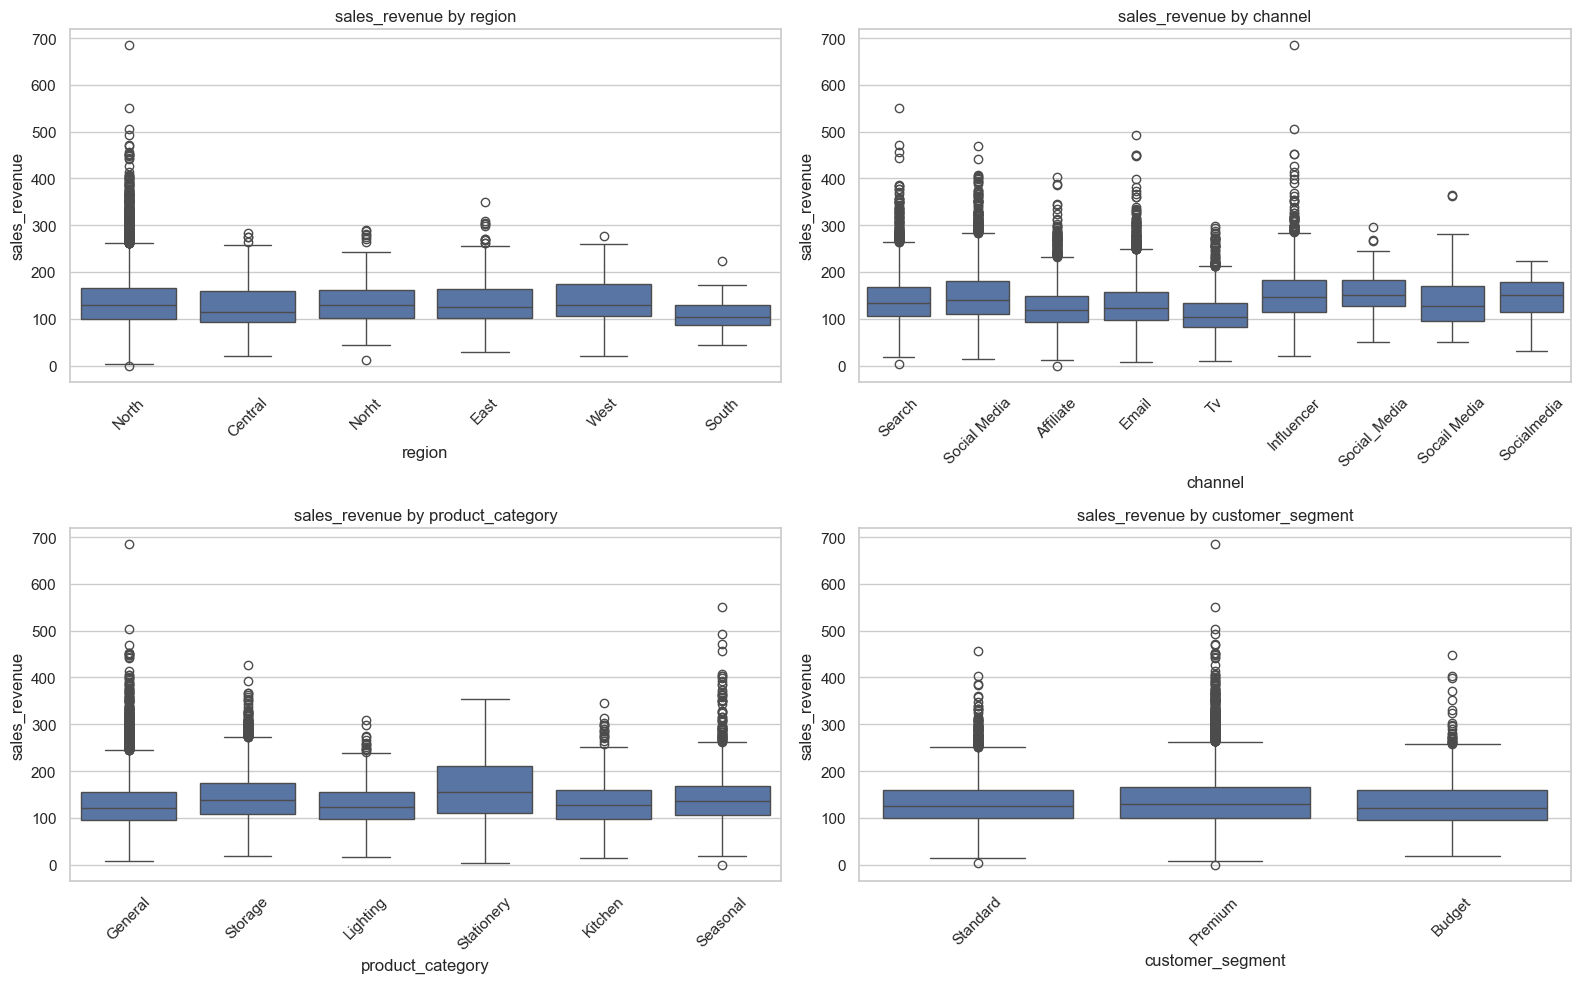

In [16]:
# Distribution of sales_revenue across categories (boxplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(["region", "channel", "product_category", "customer_segment"]):
    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
    axes[i].set_title(f"{target} by {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

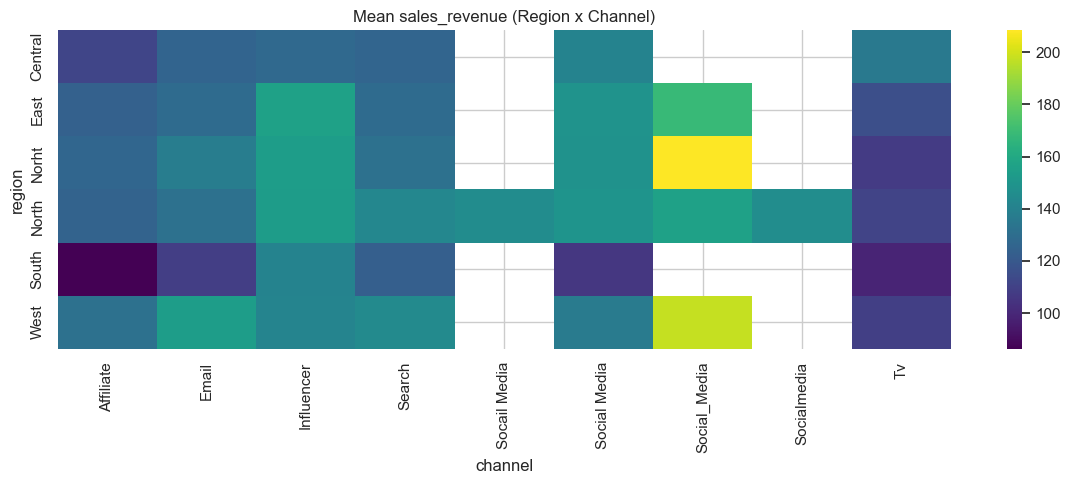

channel,Affiliate,Email,Influencer,Search,Socail Media,Social Media,Social_Media,Socialmedia,Tv
region,,,,,,,,,
Central,111.549665,125.260412,127.494443,125.894147,NaN,140.792099,NaN,NaN,135.521715
East,123.984945,128.686280,156.113752,128.789966,NaN,149.073596,168.398921,NaN,115.478007
Norht,126.135884,137.554338,153.910969,131.209803,NaN,147.887874,208.362345,NaN,107.465040
North,124.964740,131.357699,153.115981,142.896992,145.161464,149.627009,156.000692,145.575544,111.103983
South,86.417503,108.525103,141.031423,122.869234,NaN,105.660951,NaN,NaN,98.564898


In [17]:
# Interaction: Region x Channel (mean sales)
pivot = pd.pivot_table(
    df,
    index="region",
    columns="channel",
    values=target,
    aggfunc="mean",
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=False, cmap="viridis")
plt.title("Mean sales_revenue (Region x Channel)")
plt.tight_layout()
plt.show()

pivot.head()

### Insights (categorical)

Use the plots above to answer:
- Which **channel** drives higher revenue on average?
- Which **region** performs best/worst?
- Which **customer segment** is the most valuable?
- Do some region-channel combinations consistently outperform others?


## 8) Analysis on numerical attributes

We inspect:
- Distributions & skewness
- Outliers (IQR/Tukey)
- Correlations


In [18]:
df_num = df[nums].copy()
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
ad_spend,17342.0,44.071797,190.165450,0.180000,4.950000,11.900000,19.800000,4254.500000
price,18000.0,5.648265,22.456661,0.040000,1.250000,1.950000,3.750000,295.000000
discount_rate,17245.0,0.230045,0.149955,0.000200,0.109500,0.204000,0.324900,0.600000
market_reach,17314.0,321.393323,244.853653,1.000000,138.000000,269.000000,439.000000,1490.000000
impressions,18000.0,7257.423889,7600.666112,-30771.000000,2503.750000,5106.500000,9566.250000,173986.000000
click_through_rate,17287.0,0.057141,0.049452,0.000000,0.020450,0.043500,0.079900,0.435700
competition_index,17293.0,4.004004,1.994997,0.040000,2.440000,3.870000,5.410000,9.650000
seasonality_index,18000.0,-0.014902,0.919343,-1.366025,-1.000000,0.366025,1.000000,1.366025
campaign_duration_days,16487.0,35.565597,27.039417,7.000000,14.000000,28.000000,60.000000,90.000000
customer_lifetime_value,17257.0,10317.172008,35581.519328,0.550000,573.110000,1781.440000,5502.780000,543228.100000


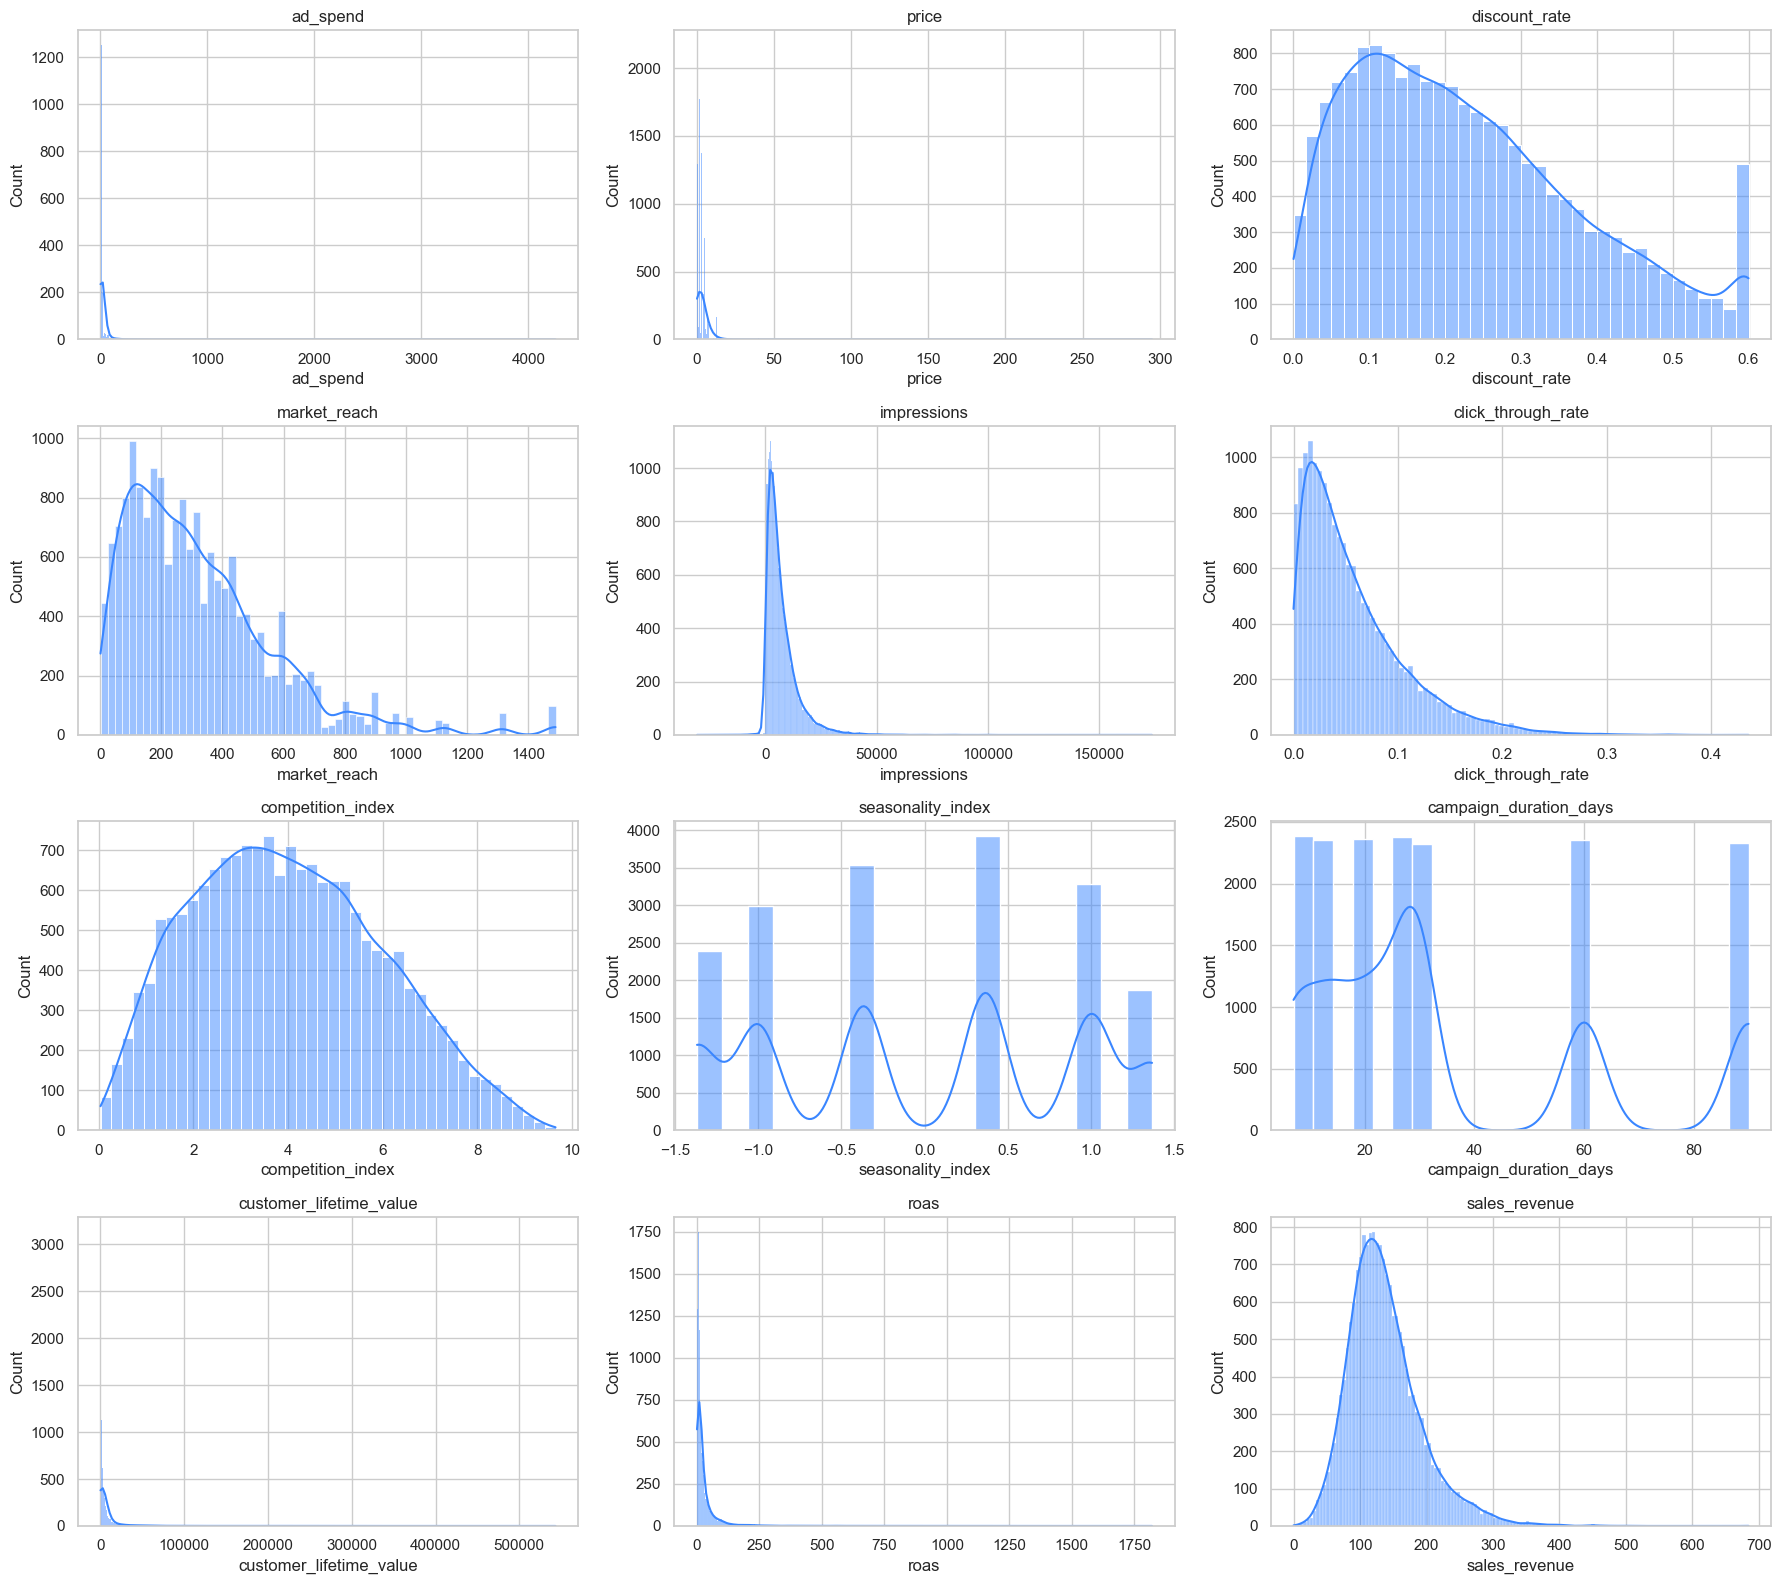

In [19]:
# Distribution plots for key numeric features
key_nums = [
    "ad_spend",
    "price",
    "discount_rate",
    "market_reach",
    "impressions",
    "click_through_rate",
    "competition_index",
    "seasonality_index",
    "campaign_duration_days",
    "customer_lifetime_value",
    "roas",
    "sales_revenue",
]
key_nums = [c for c in key_nums if c in df.columns]

ncols = 3
nrows = int(np.ceil(len(key_nums) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_nums):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#3a86ff")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

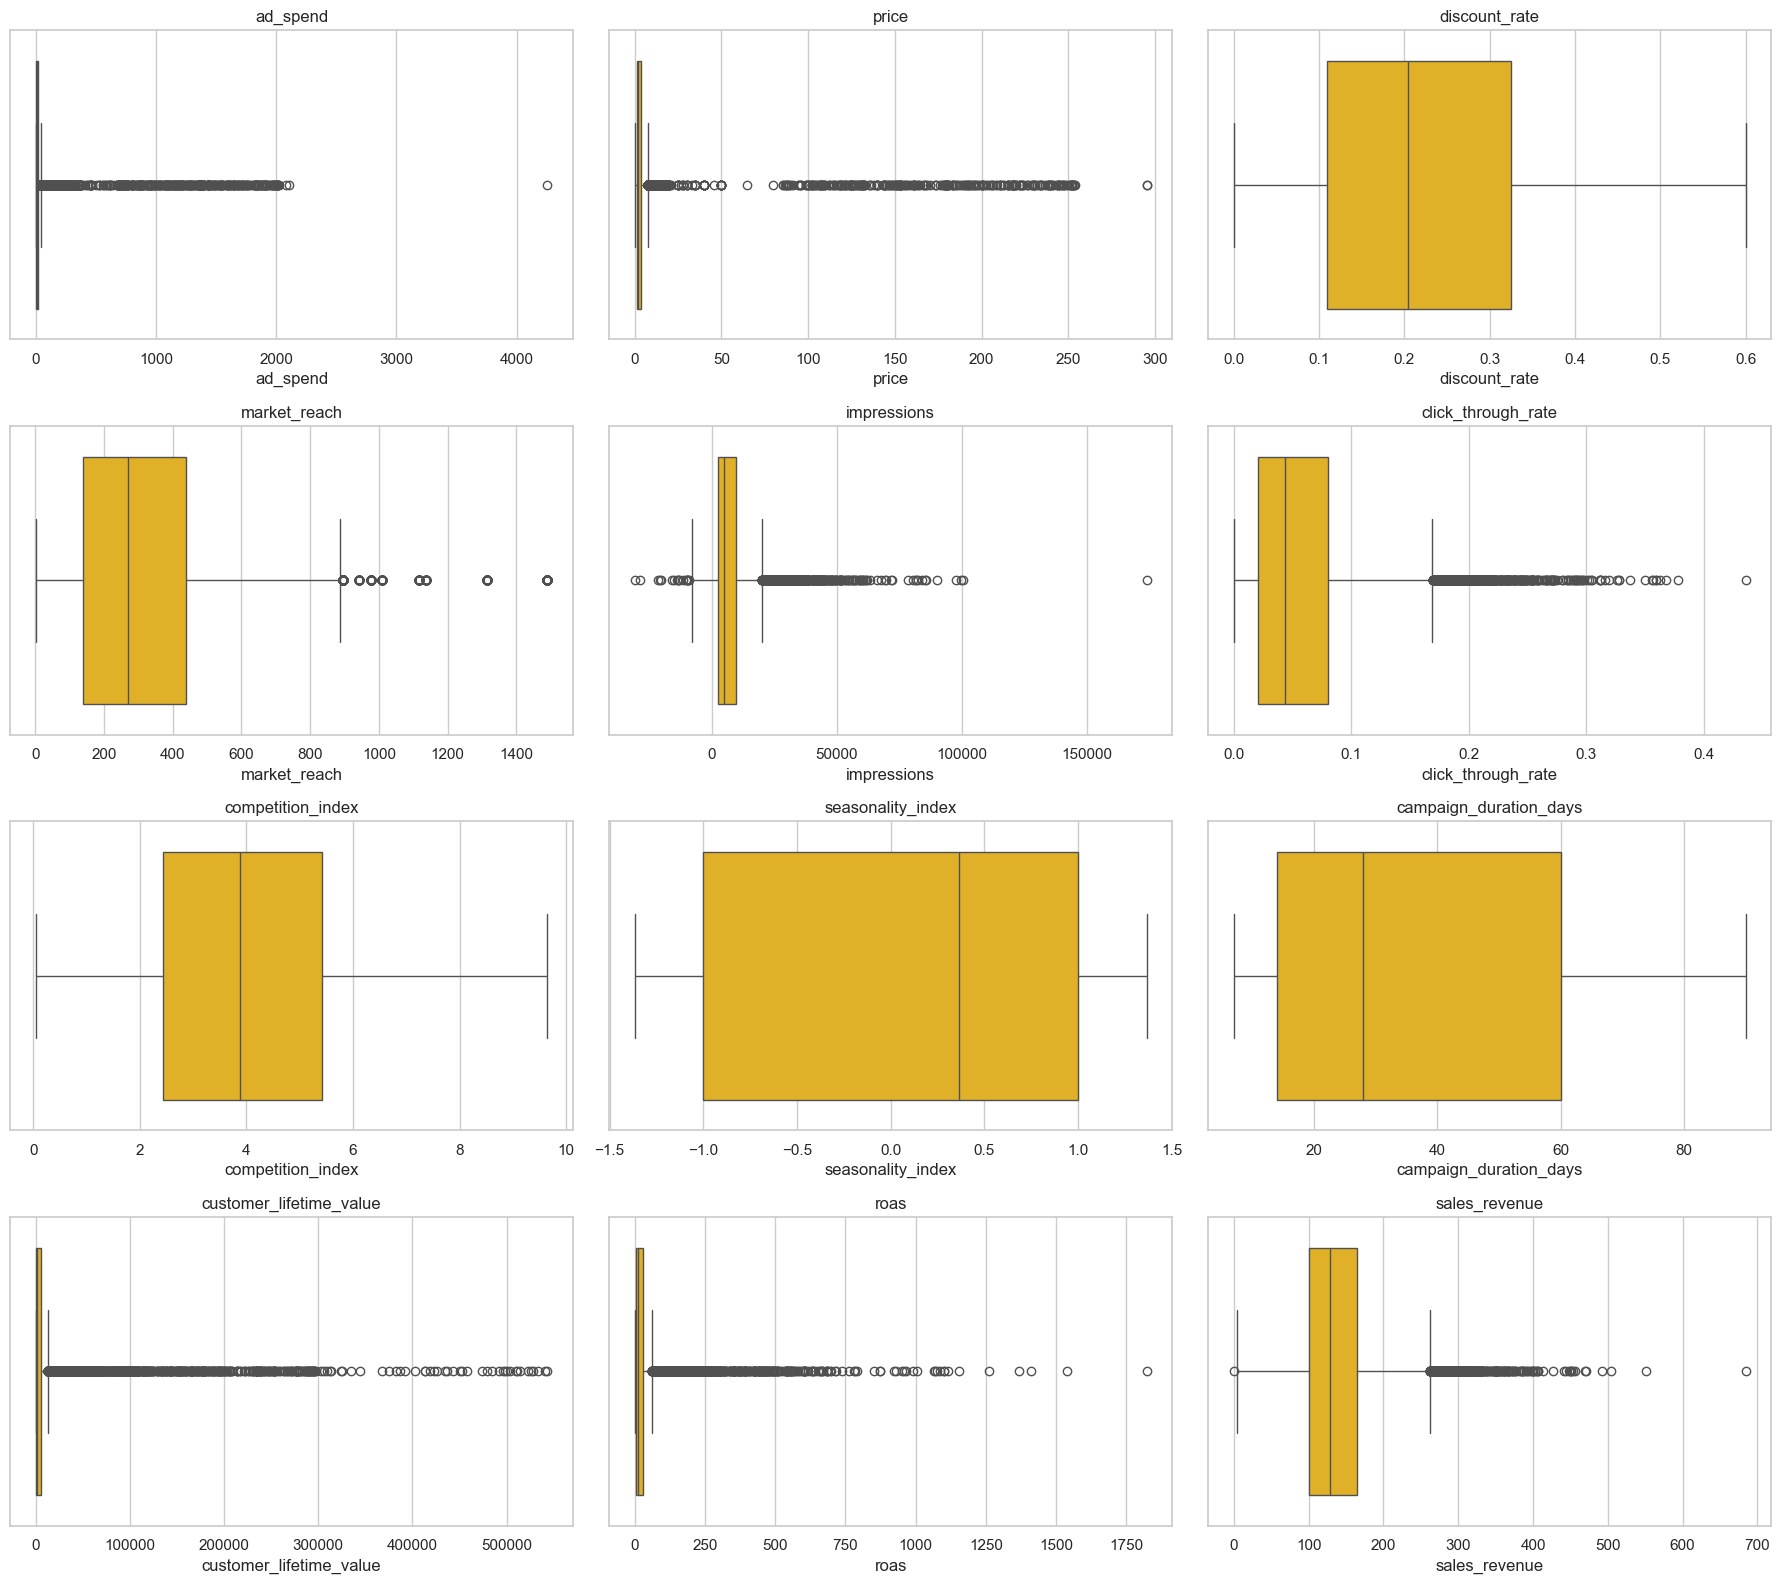

In [20]:
# Boxplots for outlier check
ncols = 3
nrows = int(np.ceil(len(key_nums) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_nums):
    sns.boxplot(x=df[col], ax=axes[i], color="#ffbe0b")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
def tukey_outliers(series: pd.Series) -> pd.Index:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return series[(series < low) | (series > high)].index

outlier_summary = []
for col in key_nums:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    idx = tukey_outliers(s)
    outlier_summary.append({"feature": col, "outlier_rows": len(idx), "outlier_pct": round(len(idx) / len(df) * 100, 2)})

pd.DataFrame(outlier_summary).sort_values("outlier_rows", ascending=False)

,feature,outlier_rows,outlier_pct
9,customer_lifetime_value,2140,11.89
10,roas,1950,10.83
1,price,1688,9.38
0,ad_spend,1643,9.13
4,impressions,1015,5.64
5,click_through_rate,653,3.63
11,sales_revenue,574,3.19
3,market_reach,553,3.07
2,discount_rate,0,0.00
6,competition_index,0,0.00


### Correlation analysis

We compute Pearson correlation between numeric features (use Spearman for monotonic non-linear relationships).


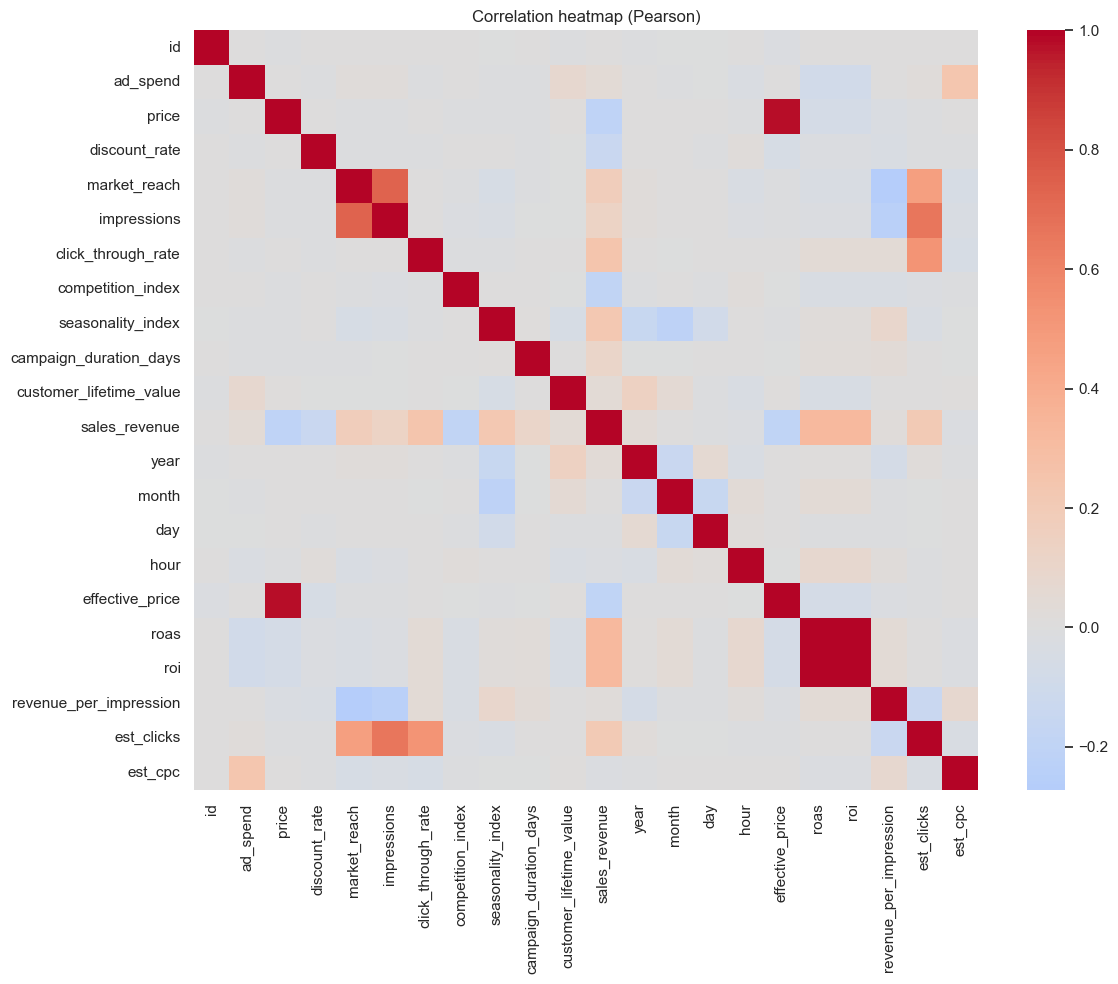

In [22]:
num_for_corr = df.select_dtypes(include=[np.number]).columns
corr = df[num_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (Pearson)")
plt.tight_layout()
plt.show()

In [23]:
# Correlation with target (Spearman often more robust for skewed features)
spearman_to_target = df[num_for_corr].corrwith(df[target], method="spearman").sort_values(ascending=False)
spearman_to_target.to_frame("spearman_corr_with_sales")

,spearman_corr_with_sales
sales_revenue,1.000000
roas,0.374831
roi,0.374831
est_clicks,0.307495
seasonality_index,0.246253
click_through_rate,0.240871
market_reach,0.240734
impressions,0.203570
revenue_per_impression,0.173623
campaign_duration_days,0.107585


## 9) Numerical vs target relationships

Scatter/regression plots help identify patterns and potential non-linear effects.


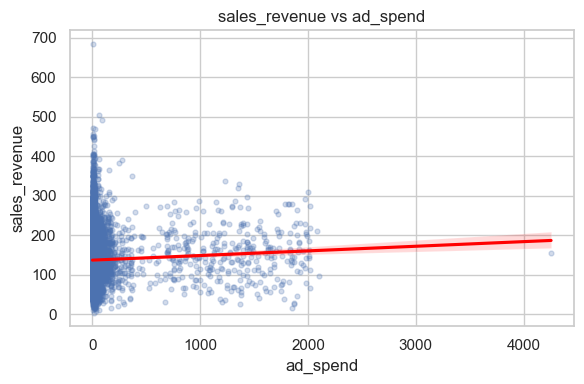

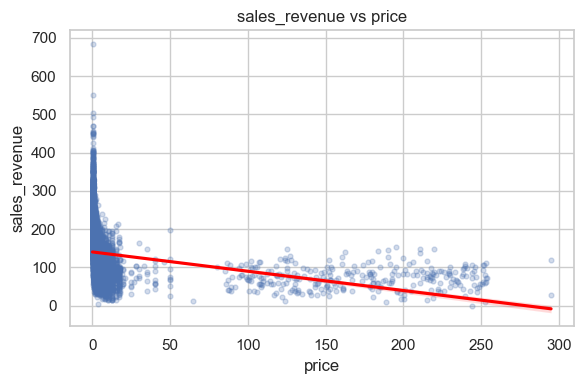

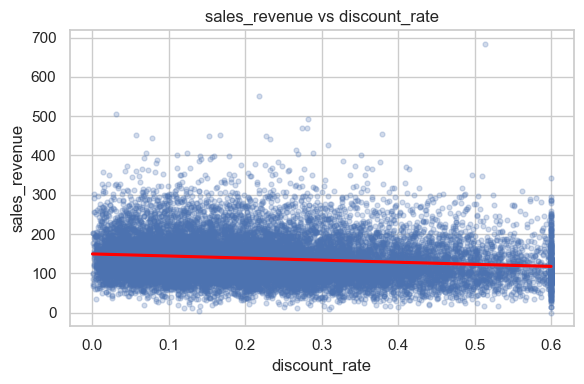

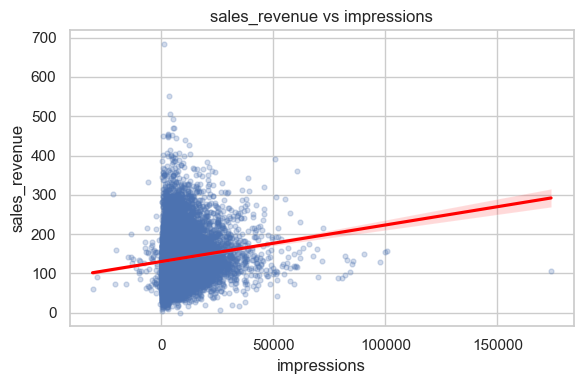

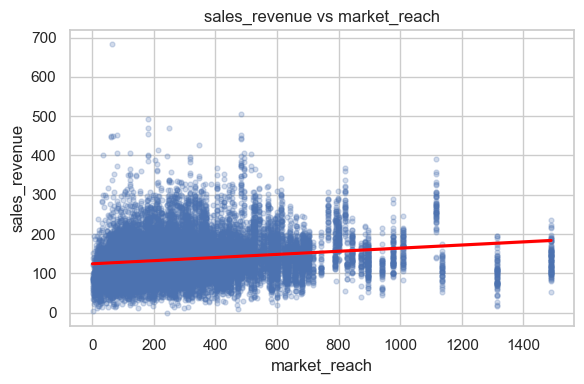

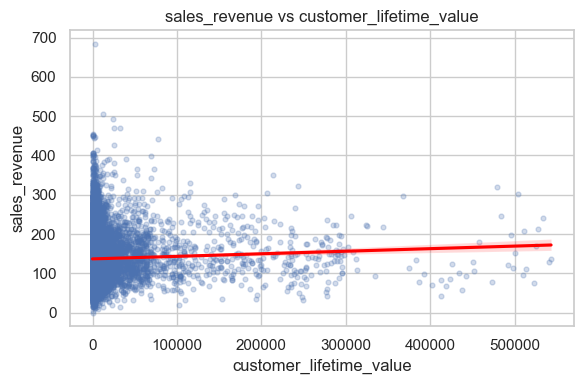

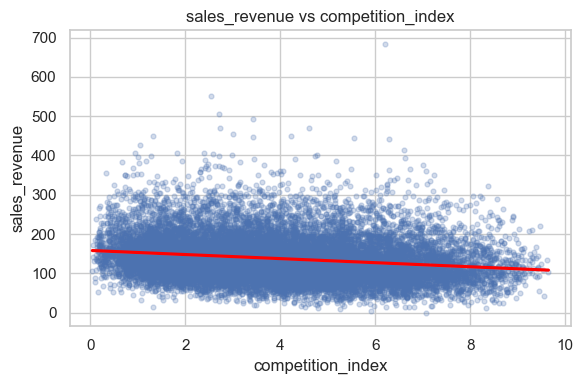

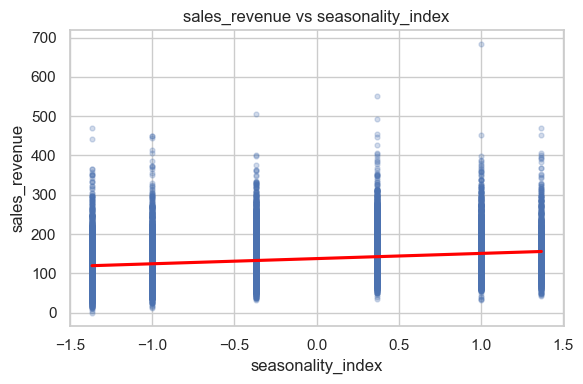

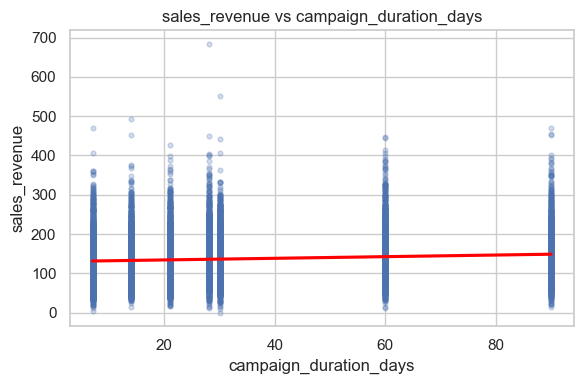

In [24]:
def regplot_safe(dataframe: pd.DataFrame, x: str, y: str, logx=False, logy=False):
    tmp = dataframe[[x, y]].dropna().copy()
    if logx:
        tmp[x] = np.log1p(tmp[x])
    if logy:
        tmp[y] = np.log1p(tmp[y])

    plt.figure(figsize=(6, 4))
    sns.regplot(data=tmp, x=x, y=y, scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "red"})
    plt.title(f"{y} vs {x}" + (" (log1p)" if (logx or logy) else ""))
    plt.tight_layout()
    plt.show()

for x in ["ad_spend", "price", "discount_rate", "impressions", "market_reach", "customer_lifetime_value", "competition_index", "seasonality_index", "campaign_duration_days"]:
    if x in df.columns:
        regplot_safe(df, x, target, logx=False, logy=False)

## 10) Time-based analysis

We analyze revenue trends over time, and how channel/segment mixes change.


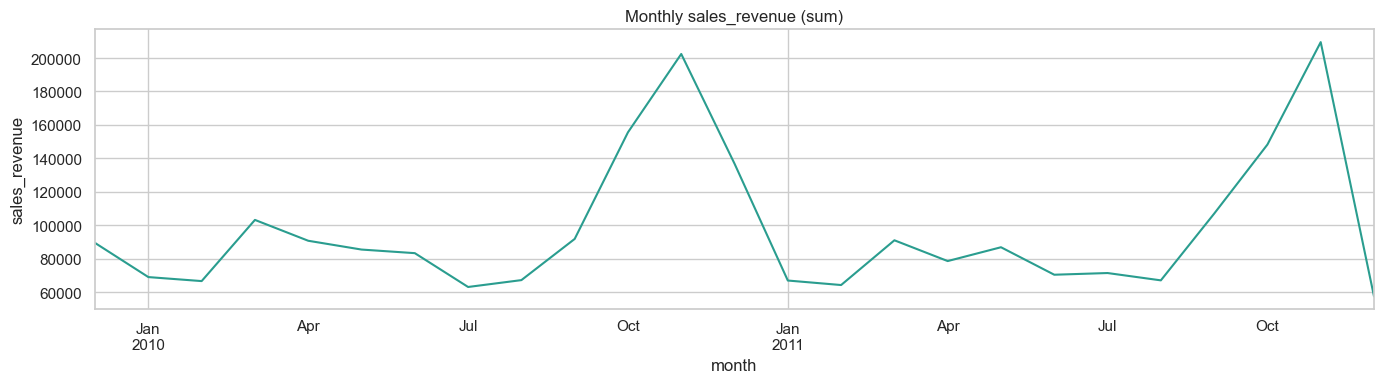

date
2009-12-01     89425.593714
2010-01-01     69023.404954
2010-02-01     66627.927902
2010-03-01    103209.865266
2010-04-01     90742.881170
Freq: MS, Name: sales_revenue, dtype: float64

In [25]:
df_time = df.dropna(subset=["date"]).set_index("date").sort_index()

monthly_sales = df_time[target].resample("MS").sum()

plt.figure(figsize=(14, 4))
monthly_sales.plot(color="#2a9d8f")
plt.title("Monthly sales_revenue (sum)")
plt.xlabel("month")
plt.ylabel("sales_revenue")
plt.tight_layout()
plt.show()

monthly_sales.head()

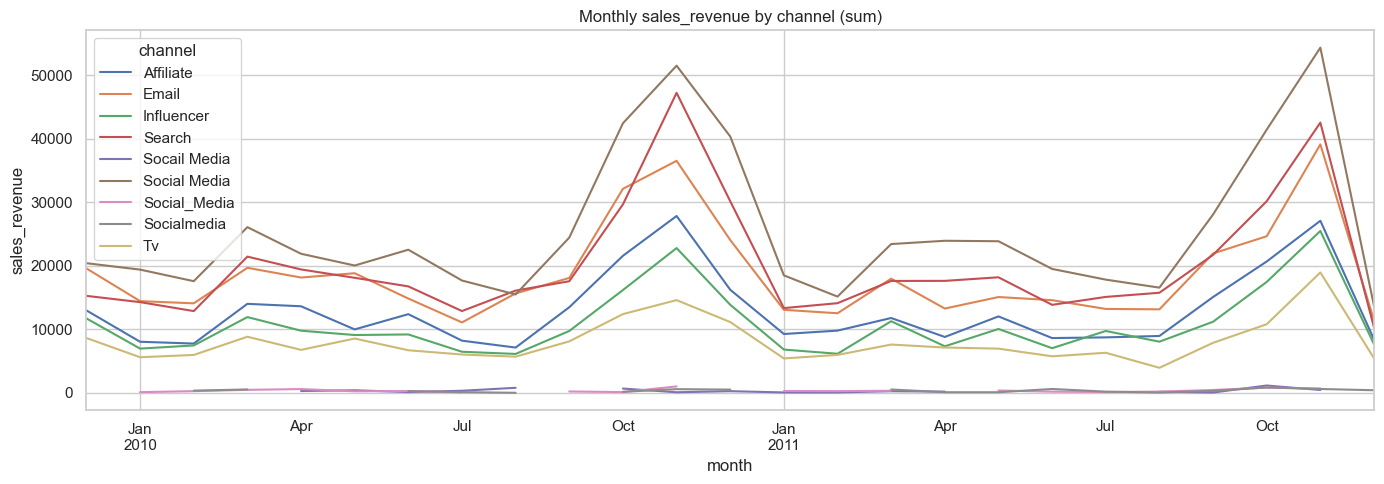

channel,Affiliate,Email,Influencer,Search,Socail Media,Social Media,Social_Media,Socialmedia,Tv
date,,,,,,,,,
2009-12-01,13002.545001,19614.022555,11742.998333,15294.595122,106.694320,20438.272389,NaN,572.079206,8654.386789
2010-01-01,8067.512900,14465.712254,6990.699208,14308.158247,NaN,19428.334857,132.980746,NaN,5630.006743
2010-02-01,7785.033136,14119.708571,7488.377226,12899.591138,74.604533,17607.093628,290.424712,370.280805,5992.814152
2010-03-01,14039.235966,19712.679629,11954.186743,21475.015147,NaN,26115.330617,494.862210,559.880164,8858.674790
2010-04-01,13656.850883,18181.744141,9808.585595,19454.284115,310.402627,21923.343517,616.456353,NaN,6791.213940


In [26]:
# Monthly revenue by channel
monthly_by_channel = df_time.pivot_table(values=target, index=pd.Grouper(freq="MS"), columns="channel", aggfunc="sum")

plt.figure(figsize=(14, 5))
monthly_by_channel.plot(ax=plt.gca())
plt.title("Monthly sales_revenue by channel (sum)")
plt.xlabel("month")
plt.ylabel("sales_revenue")
plt.tight_layout()
plt.show()

monthly_by_channel.head()

## 11) KPI deep-dive (ROAS/ROI)

ROAS/ROI can be more informative than revenue alone, especially for marketing efficiency.


In [27]:
kpi_cols = ["roas", "roi", "revenue_per_impression", "est_cpc"]

df_kpi = df[kpi_cols + ["channel", "customer_segment", target]].copy()

summary = df_kpi.groupby("channel")[kpi_cols + [target]].agg(["mean", "median"]).round(4)
summary

roas               roi          revenue_per_impression         est_cpc         sales_revenue          
                 mean   median     mean   median                   mean  median    mean  median          mean    median
channel                                                                                                                
Affiliate     29.0958   9.9628  28.0958   8.9628                 0.0440  0.0227  1.0115  0.0530      124.8944  117.8359
Email         29.3905  10.1860  28.3905   9.1860                 0.0507  0.0250  2.4046  0.0561      131.3528  123.8242
Influencer    34.7868  12.4480  33.7868  11.4480                 0.0593  0.0294  1.0791  0.0550      153.0519  145.8185
Search        33.1807  11.6857  32.1807  10.6857                 0.0565  0.0264  1.2568  0.0549      142.3012  134.3492
Socail Media  49.5507  10.6207  48.5507   9.6207                 0.0526  0.0263  0.4423  0.0606      145.1615  127.2182
Social Media  33.6223  11.9025  32.6223  10.9025                 0.0561  0.0273  1.4691  0.0546      149.3812  140.5271
Social_Media  27.9466  14.9120  26.9466  13.9120                 0.0386  0.0258  0.2185  0.0374      158.2152  150.8866
Socialmedia   32.7646  11.1381  31.7646  10.1381                 0.0567  0.0260  0.1831  0.0419      145.5755  149.8201
Tv            26.8199   8.8096  25.8199   7.8096                 0.0438  0.0214  0.7613  0.0574      111.2018  104.3302

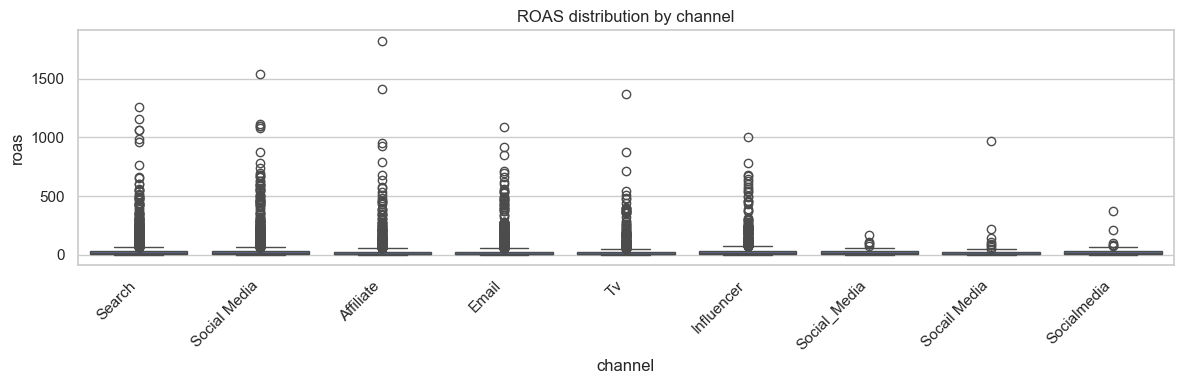

In [28]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x="channel", y="roas")
plt.title("ROAS distribution by channel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

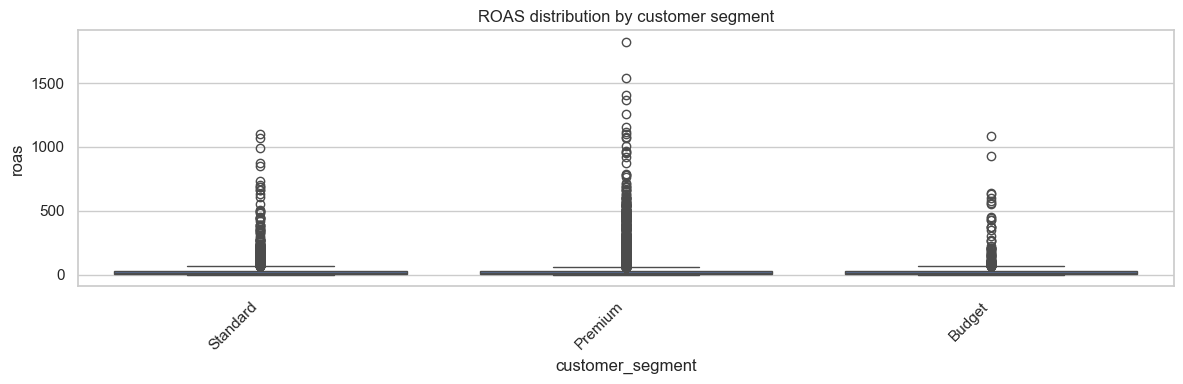

In [29]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x="customer_segment", y="roas")
plt.title("ROAS distribution by customer segment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12) Segment-level performance

We compare revenue and efficiency across segment and product categories.


In [30]:
seg_prod = (
    df.groupby(["customer_segment", "product_category"], dropna=False)
    .agg(
        rows=("id", "count"),
        sales_sum=(target, "sum"),
        sales_mean=(target, "mean"),
        ad_spend_sum=("ad_spend", "sum"),
        roas_mean=("roas", "mean"),
    )
    .sort_values("sales_sum", ascending=False)
)
seg_prod.head(15)

rows      sales_sum  sales_mean   ad_spend_sum  roas_mean
customer_segment product_category                                                           
Premium          General           7209  941076.681842  130.541917  298432.601571  31.985635
                 Storage           3090  453175.582103  146.658764  139313.724975  29.405449
                 Seasonal          1476  212832.275319  144.195308   67703.490594  29.788018
                 Stationery        1176  193175.128928  164.264565   49748.505710  31.866191
Standard         General           1370  173576.836368  126.698421   59241.972989  35.809691
Premium          Kitchen            839  110604.786252  131.829304   32402.905162  32.058356
                 Lighting           655   84097.008475  128.392379   29380.344306  18.373263
Standard         Storage            534   76790.003847  143.801505   21200.328710  37.781171
Budget           General            405   51429.215215  126.985717   21319.257492  38.371808
Standard         Seasonal           324   44527.092499  137.429298   12171.747845  35.647808
                 Stationery         236   36687.690427  155.456315    8190.390851  28.854285
                 Kitchen            164   21389.297238  130.422544    7313.998150  29.230915
Budget           Storage            151   20488.447375  135.685082    3562.441955  40.286988
Standard         Lighting           136   16888.657717  124.181307    4554.511873  25.089784
Budget           Seasonal            78   11396.211315  146.105273    2797.189337  37.402344

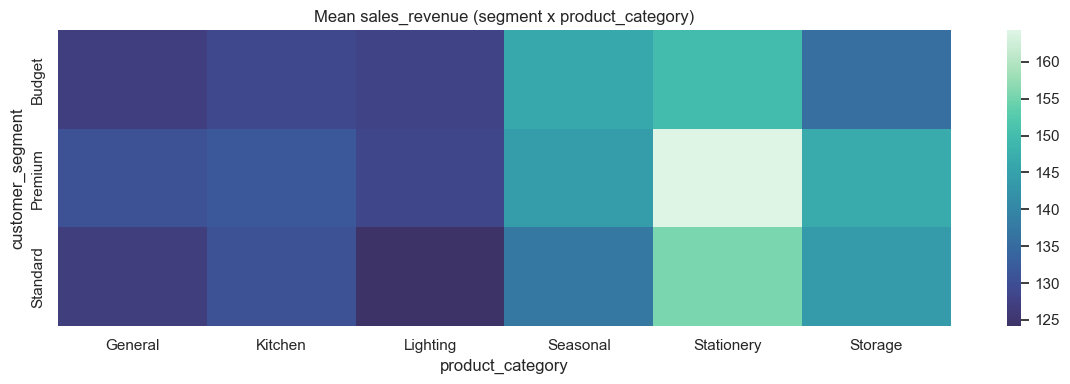

In [31]:
# Heatmap: mean sales by segment x category
heat = df.pivot_table(index="customer_segment", columns="product_category", values=target, aggfunc="mean")

plt.figure(figsize=(12, 4))
sns.heatmap(heat, cmap="mako", center=np.nanmean(heat.values))
plt.title("Mean sales_revenue (segment x product_category)")
plt.tight_layout()
plt.show()

## 13) Final notes / conclusions

After running the notebook, summarize:
- Top channels by **revenue** vs by **ROAS** (efficiency)
- The impact of **discount_rate** on revenue (positive/negative, threshold effects)
- Whether higher **impressions** or **market_reach** reliably translate to sales
- Segment/category combinations worth prioritizing

Optional: Save the cleaned dataset for modeling.


In [34]:
# Optional: export cleaned dataframe
df.to_csv("ecommerce_clean.csv", index=False)
df.shape

(18000, 28)